# Car Racing

### Setup

In [22]:
import time
from enum import Enum

import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn

import matplotlib.pyplot as plt

### Env

https://gymnasium.farama.org/environments/box2d/car_racing/

**Action Space**
If continuous there are 3 actions :

0: steering, -1 is full left, +1 is full right
1: gas
2: braking

If discrete there are 5 actions:

0: do nothing
1: steer right
2: steer left
3: gas
4: brake

**Observation Space**
A top-down 96x96 RGB image of the car and race track.

**Rewards**
The reward is -0.1 every frame and +1000/N for every track tile visited, where N is the total number of tiles visited in the track. For example, if you have finished in 732 frames, your reward is 1000 - 0.1*732 = 926.8 points.

In [5]:
env_name = "CarRacing-v3"
render_mode = "rgb_array"
continuous = False
randomize = False

env = gym.make(env_name, render_mode=render_mode, lap_complete_percent=0.95, domain_randomize=randomize, continuous=continuous)
env

<TimeLimit<OrderEnforcing<PassiveEnvChecker<CarRacing<CarRacing-v3>>>>>

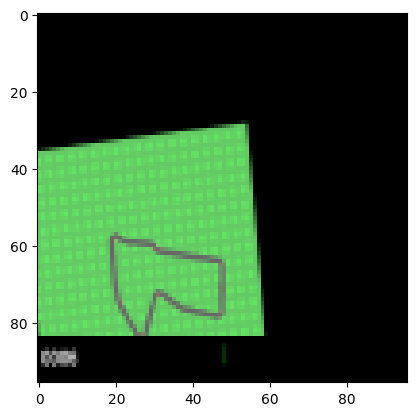

In [20]:
obs, _ = env.reset(options={"randomize": randomize})
plt.imshow(obs)

In [27]:
class Actions(Enum):
    NOTHING = 0
    RIGHT = 1
    LEFT = 2
    GAS = 3
    BRAKE = 4

Reward: 7.042857142857144
Terminated: False
Truncated: False
Info:
{}


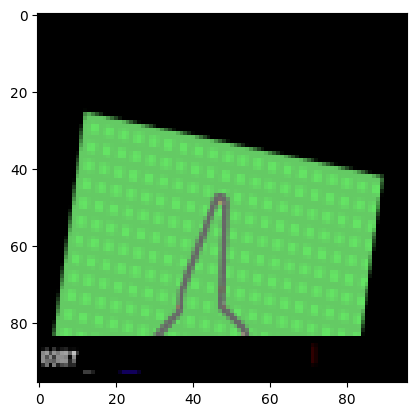

In [41]:
env.reset()
obs, reward, terminated, truncated, info = env.step(action=Actions.GAS.value)

plt.imshow(obs)
print(f"Reward: {reward}")
print(f"Terminated: {terminated}")
print(f"Truncated: {truncated}")
print(f"Info:\n{info}")

### Value Function

In [ ]:
# NOTE: IMAGE PIXEL VALUES ARE IN 0-255 RANGE - NORMALIZE BEFORE PROCESSING!

In [73]:
def preprocess_observation(obs: np.ndarray) -> torch.Tensor:
    obs = obs / 255.0 # Normalize pixel values to [0, 1]
    obs = np.moveaxis(obs, -1, 0) # Change ordering: (H, W, C) -> (C, H, W)
    obs_tensor = torch.tensor(data=obs, dtype=torch.float32)
    obs_tensor = obs_tensor.unsqueeze(0) # Add batch dimension: (B, C, H, W)
    return obs_tensor

In [114]:
class CNN_Q_VFA(nn.Module):
    """
    CNN that maps state -> Q-values for each action.
    """
    def __init__(self, action_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            # Embedder
            nn.Conv2d(in_channels=3, out_channels=8, kernel_size=5, stride=1), # in: (b, 3, 96, 96) -> out: (b, 8, 92, 92)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # in: (b, 8, 92, 92) -> out: (b, 8, 46, 46)
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=5, stride=1), # in: (b, 8, 46, 46) -> out: (b, 16, 42, 42)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # in: (b, 16, 42, 42) -> out: (b, 16, 21, 21)
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1), # in: (b, 16, 21, 21) -> out: (b, 32, 17, 17)
            nn.ReLU(),
            nn.Flatten(), # in: (b, 32, 17, 17) -> out: (b, 9248)
            # Regressor
            nn.Linear(in_features=9248, out_features=512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(in_features=512, out_features=128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(in_features=128, out_features=action_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [118]:
test_cnn = CNN_Q_VFA(action_dim=Actions._member_map_.__len__())
test_cnn(preprocess_observation(obs))

tensor([[-0.0690,  0.0207,  0.0689,  0.0877,  0.0243]],
       grad_fn=<AddmmBackward0>)

### Agent

In [ ]:
class RacingAgent():
    def __init__(self):
        ...